<a href="https://colab.research.google.com/github/Bukunmi2108/ml-journey/blob/main/research/p1/moe/moe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import tiktoken
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import urllib.request as req

In [92]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

In [93]:
try:
    with req.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    print("Total Length", len(raw_text))
except:
    print("Text download failed")

Total Length 1115394


In [94]:
corpus = raw_text[:150]
print("Corpus Excerpt: \n", "="*30, "\n", corpus)

Corpus Excerpt: 
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

A


In [95]:
enc = tiktoken.encoding_for_model("gpt-4o")
token_ids = enc.encode(raw_text)
vocab_size = enc.max_token_value + 1

In [96]:
data_tensor = torch.tensor(token_ids, dtype=torch.long)

Parameters

In [97]:
block_size = 128
batch_size = 16
top_k = 2
num_experts = 8
num_heads = 4
num_layers = 4
d_model = 64
d_ff = 4 * d_model
learning_rate = 1e-3
max_iters = 1000
eval_interval = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Train/Val Split

In [98]:
n = int(0.9 * len(data_tensor))
train_data = data_tensor[:n]
val_data = data_tensor[n:]

Batching

In [99]:
def get_batch(split, device):
    data = train_data if split == "train" else val_data
    ix = torch.randint(0, len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Verifying Batching

In [100]:
x, y = get_batch("train", device)
assert x.shape == (batch_size, block_size)
assert y.shape == (batch_size, block_size)

Noisy TopK Router

In [101]:
class NoisyTopKRouter(nn.Module):
    def __init__(self, d_model: int, num_experts: int, top_k: int = 2):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.gate = nn.Linear(d_model, num_experts, bias=False)
        self.w_noise = nn.Linear(d_model, num_experts, bias=False)

    def forward(self, x_flat: torch.Tensor):
        clean_logits = self.gate(x_flat)

        if self.training:
            noise_scale = F.softplus(self.w_noise(x_flat))
            noise = torch.rand_like(clean_logits) * noise_scale
            logits = clean_logits + noise
        else:
            logits = clean_logits

        probs = torch.softmax(logits, dim=-1)
        topk_weights, topk_indices = torch.topk(probs, self.top_k, dim=-1)
        topk_weights = topk_weights / topk_weights.sum(dim=-1, keepdim=True)

        importance = probs.sum(dim=0)
        top1_indices = topk_indices[:, 0]
        load = torch.bincount(top1_indices, minlength=self.num_experts).float()
        num_tokens = x_flat.size(0)
        aux_loss = self.num_experts * torch.sum((importance / num_tokens) * (load / num_tokens))
        return topk_weights, topk_indices, aux_loss

Expert

In [102]:
class Expert(nn.Module):
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.act = nn.GELU()
        self.w2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.w2(self.act(self.w1(x)))

MOELayer

In [103]:
class MOELayer(nn.Module):
    def __init__(self, d_model: int, d_ff: int, num_experts: int, top_k: int):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.router = NoisyTopKRouter(d_model, num_experts, top_k)
        self.experts = nn.ModuleList([Expert(d_model, d_ff) for _ in range(num_experts)])

    def forward(self, x: torch.Tensor):
        orig_shape = x.shape
        x_flat = x.view(-1, orig_shape[-1])
        topk_weights, topk_indices, aux_loss = self.router(x_flat)
        out_flat = torch.zeros_like(x_flat)

        for i, expert in enumerate(self.experts):
            token_indices, topk_positions = (topk_indices == i).nonzero(as_tuple=True)
            if token_indices.numel() == 0:
                continue

            expert_outputs = expert(x_flat[token_indices])

            weights = topk_weights[token_indices, topk_positions].unsqueeze(-1)
            out_flat[token_indices] += weights * expert_outputs
        return out_flat.view(orig_shape), aux_loss

Transformer Block

In [104]:
class TranformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, num_experts: int, top_k):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.moe = MOELayer(d_model, d_ff, num_experts, top_k)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor):
        attn_out, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x))
        x = x + attn_out
        moe_out, aux_loss = self.moe(self.ln2(x))
        x = x + moe_out
        return x, aux_loss

MOE Transformer

In [105]:
class MOETranformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, d_ff: int, num_heads: int, num_layers: int, num_experts: int, top_k: int):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, 1024, d_model))
        self.layers = nn.ModuleList([TranformerBlock(d_model, num_heads, d_ff, num_experts, top_k) for _ in range(num_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, tokens: torch.Tensor, targets = None):
        b, t = tokens.shape
        x = self.token_emb(tokens) + self.pos_emb[:, :t, :]
        total_aux_loss = 0.0
        for layer in self.layers:
            x, aux_loss = layer(x)
            total_aux_loss += aux_loss
        logits = self.lm_head(self.ln_f(x))

        loss = None
        if targets is not None:
            ce_loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            loss = ce_loss + 0.01 * total_aux_loss
        return logits, loss

Estimating Loss

In [106]:
@torch.no_grad()
def estimate_loss(model, device, eval_interval):
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_interval)
        for k in range(eval_interval):
            x_batch, y_batch = get_batch(split, device)
            logits, loss = model(x_batch, y_batch)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

Training

In [107]:
model = MOETranformer(vocab_size, d_model, d_ff, num_heads, num_layers, num_experts, top_k).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
tl_history, vl_history = {}, {}

for step in range(max_iters):
    x_batch, y_batch = get_batch("train", device)
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % eval_interval == 0:
        losses = estimate_loss(model, device, eval_interval)
        tl_history[step] = losses["train"]
        vl_history[step] = losses["val"]
        print(f"Step {step:4d} | Train Loss: {losses['train']:.5f} | Val Loss: {losses['val']:.5f}")

Step    0 | Train Loss: 12.34777 | Val Loss: 12.34658
Step  100 | Train Loss: 6.78875 | Val Loss: 7.08960
Step  200 | Train Loss: 5.91818 | Val Loss: 6.45783
Step  300 | Train Loss: 5.43997 | Val Loss: 6.16876
Step  400 | Train Loss: 5.15262 | Val Loss: 5.93139
Step  500 | Train Loss: 4.90984 | Val Loss: 5.80646
Step  600 | Train Loss: 4.78155 | Val Loss: 5.70178
Step  700 | Train Loss: 4.60664 | Val Loss: 5.68668
Step  800 | Train Loss: 4.51414 | Val Loss: 5.60695
Step  900 | Train Loss: 4.36728 | Val Loss: 5.61030


Plot Curves

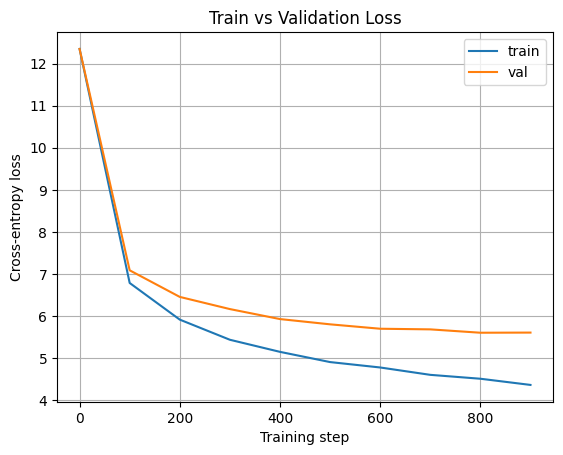

In [108]:
plt.plot(tl_history.keys(), tl_history.values(), label="train")
plt.plot(vl_history.keys(), vl_history.values(), label="val")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Testing

In [109]:
def generate_text(model, prompt, max_new_tokens=20, temperature=0.7):
    model.eval()
    generated_indices = enc.encode(prompt)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = generated_indices[-block_size:]
            input_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits, _ = model(input_tensor)
            next_token_logits = logits[0, -1, :] / temperature
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            generated_indices.append(next_token)
    return enc.decode(generated_indices)

In [113]:
prompt = "you are"
print(generate_text(model, prompt, max_new_tokens=20))

you are with a pretty are a man of a flower of a poor brother of a kind of their men of
